In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              confusion_matrix)
import xgboost as xgb
import joblib
import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries imported!')

✅ Libraries imported!


In [2]:
X_train = pd.read_csv('../data/X_train.csv')
X_test = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').values.ravel()
y_test = pd.read_csv('../data/y_test.csv').values.ravel()

print('✅ Data loaded!')
print(f'📊 X_train: {X_train.shape}')
print(f'📊 X_test: {X_test.shape}')
print(f'🎯 y_train unique values: {np.unique(y_train)}')

✅ Data loaded!
📊 X_train: (806, 13)
📊 X_test: (202, 13)
🎯 y_train unique values: [0 1]


In [3]:
baseline_rf = joblib.load('../models/baseline_model.pkl')
baseline_pred = baseline_rf.predict(X_test)

baseline_f1 = f1_score(y_test, baseline_pred)
baseline_accuracy = accuracy_score(y_test, baseline_pred)

print('📊 BASELINE RANDOM FOREST (Day 7)')
print(f'Accuracy: {baseline_accuracy:.3f}')
print(f'F1-Score: {baseline_f1:.3f}')

📊 BASELINE RANDOM FOREST (Day 7)
Accuracy: 0.847
F1-Score: 0.800


In [4]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

print('🔍 Running GridSearchCV... this may take 30-60 seconds')
rf_grid.fit(X_train, y_train)

print('✅ GridSearchCV complete!')
print(f'\n🏆 Best Parameters: {rf_grid.best_params_}')
print(f'🏆 Best CV F1-Score: {rf_grid.best_score_:.3f}')

🔍 Running GridSearchCV... this may take 30-60 seconds
✅ GridSearchCV complete!

🏆 Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
🏆 Best CV F1-Score: 0.810


In [5]:
best_rf = rf_grid.best_estimator_
best_rf_pred = best_rf.predict(X_test)

tuned_accuracy = accuracy_score(y_test, best_rf_pred)
tuned_precision = precision_score(y_test, best_rf_pred)
tuned_recall = recall_score(y_test, best_rf_pred)
tuned_f1 = f1_score(y_test, best_rf_pred)

print('📊 TUNED RANDOM FOREST RESULTS')
print(f'Accuracy:  {tuned_accuracy:.3f}')
print(f'Precision: {tuned_precision:.3f}')
print(f'Recall:    {tuned_recall:.3f}')
print(f'F1-Score:  {tuned_f1:.3f}')

print(f'\n📈 Improvement over baseline:')
print(f'F1-Score: {baseline_f1:.3f} → {tuned_f1:.3f} ' +
      f'({(tuned_f1-baseline_f1)*100:+.1f}%)')

📊 TUNED RANDOM FOREST RESULTS
Accuracy:  0.842
Precision: 0.805
Recall:    0.785
F1-Score:  0.795

📈 Improvement over baseline:
F1-Score: 0.800 → 0.795 (-0.5%)


In [6]:
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)

print('📊 XGBOOST RESULTS')
print(f'Accuracy:  {xgb_accuracy:.3f}')
print(f'Precision: {xgb_precision:.3f}')
print(f'Recall:    {xgb_recall:.3f}')
print(f'F1-Score:  {xgb_f1:.3f}')

📊 XGBOOST RESULTS
Accuracy:  0.856
Precision: 0.829
Recall:    0.797
F1-Score:  0.813


In [7]:
comparison = pd.DataFrame({
    'Model': ['Baseline RF', 'Tuned RF', 'XGBoost'],
    'Accuracy': [baseline_accuracy, tuned_accuracy, xgb_accuracy],
    'Precision': [precision_score(y_test, baseline_pred),
                  tuned_precision, xgb_precision],
    'Recall': [recall_score(y_test, baseline_pred),
               tuned_recall, xgb_recall],
    'F1-Score': [baseline_f1, tuned_f1, xgb_f1]
})

print('📊 FINAL MODEL COMPARISON')
print(comparison.round(3).to_string(index=False))

best_idx = comparison['F1-Score'].idxmax()
best_model_name = comparison.loc[best_idx, 'Model']
print(f'\n🏆 Best Model Overall: {best_model_name}')

📊 FINAL MODEL COMPARISON
      Model  Accuracy  Precision  Recall  F1-Score
Baseline RF     0.847      0.816   0.785     0.800
   Tuned RF     0.842      0.805   0.785     0.795
    XGBoost     0.856      0.829   0.797     0.813

🏆 Best Model Overall: XGBoost


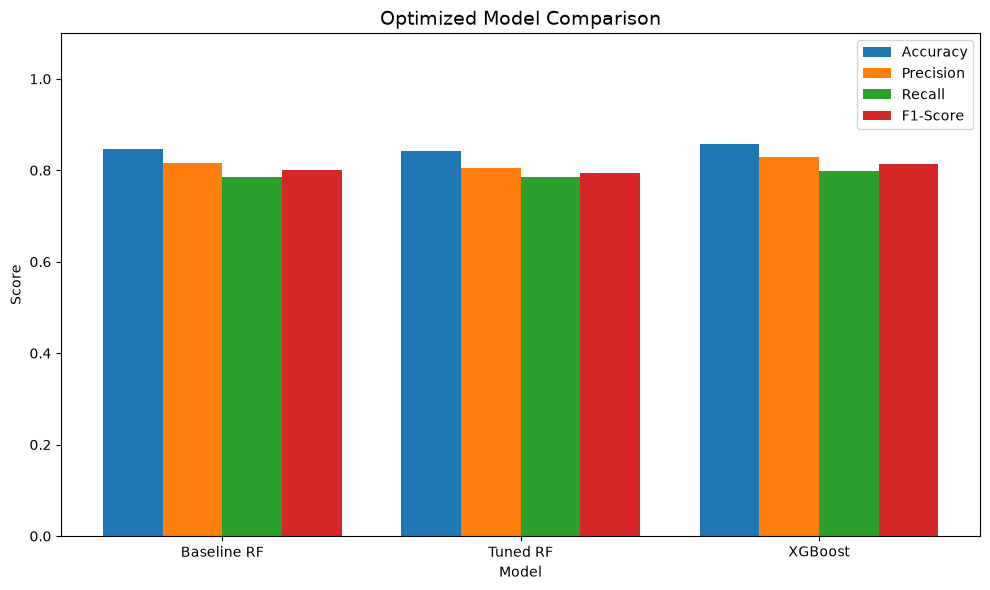

✅ Chart saved!


In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison['Model']))
width = 0.2

ax.bar(x - 1.5*width, comparison['Accuracy'], width, label='Accuracy')
ax.bar(x - 0.5*width, comparison['Precision'], width, label='Precision')
ax.bar(x + 0.5*width, comparison['Recall'], width, label='Recall')
ax.bar(x + 1.5*width, comparison['F1-Score'], width, label='F1-Score')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Optimized Model Comparison', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(comparison['Model'])
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig('../reports/optimized_model_comparison.png', dpi=150)
plt.show()
print('✅ Chart saved!')

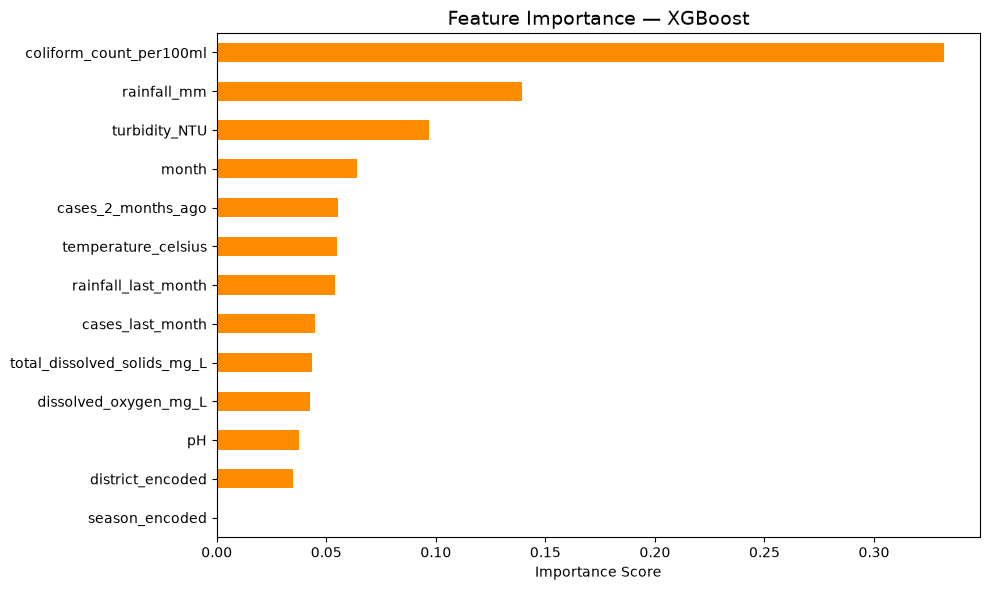

Top 5 Most Important Features (XGBoost):
coliform_count_per100ml    0.332
rainfall_mm                0.139
turbidity_NTU              0.097
month                      0.064
cases_2_months_ago         0.055
dtype: float32


In [9]:
xgb_importances = pd.Series(xgb_model.feature_importances_,
                            index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
xgb_importances.plot(kind='barh', color='darkorange')
plt.title('Feature Importance — XGBoost', fontsize=14)
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/xgboost_feature_importance.png', dpi=150)
plt.show()

print('Top 5 Most Important Features (XGBoost):')
print(xgb_importances.head(5).round(3))

In [10]:
import os
os.makedirs('../models', exist_ok=True)

# Determine which model to save based on best F1-score
models_dict = {
    'Baseline RF': baseline_rf,
    'Tuned RF': best_rf,
    'XGBoost': xgb_model
}

final_best_model = models_dict[best_model_name]
joblib.dump(final_best_model, '../models/best_model.pkl')

print(f'✅ Best model saved: models/best_model.pkl')
print(f'🏆 Model: {best_model_name}')
print(f'🏆 F1-Score: {comparison.loc[best_idx, "F1-Score"]:.3f}')
print('\n🚀 Ready for regression model and alert system!')

✅ Best model saved: models/best_model.pkl
🏆 Model: XGBoost
🏆 F1-Score: 0.813

🚀 Ready for regression model and alert system!
